# Problem Statement:
Financial institutions need to detect fraudulent card transactions quickly while minimizing false positives for legitimate
customers. The project requires learners to build a fraud detection model for highly imbalanced data and deploy it as
a scoring service.

# Project objective
 Develop a fraud detection pipeline that predicts fraud probability, evaluates performance using imbalanced
classification metrics, and exposes predictions through a simple API or dashboard.

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('/workspaces/Capstone-project-on-fraud-detection/credit_card.csv')
try:
    display(df[['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)] + ['Class']].head())
except NameError:
    print(df[['Time', 'Amount'] + [f'V{i}' for i in range(1, 29)] + ['Class']].head())

,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.0,149.62,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,0.0,2.69,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0
2,1.0,378.66,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0
3,1.0,123.50,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0
4,2.0,69.99,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0


## Performing of Exploratory Data Analysis on Dataset

In [3]:
class_distribution = df['Class'].value_counts()
print('Class Distribution:\n', class_distribution)
print('\nPercentage of each class:\n', class_distribution / len(df) * 100)

Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Percentage of each class:
 Class
0    99.827251
1     0.172749
Name: count, dtype: float64


In [3]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Create stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_test shape: {y_test.shape}')

X_train shape: (227845, 30)
y_train shape: (227845,)
X_test shape: (56962, 30)
y_test shape: (56962,)


In [4]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale 'Time' and 'Amount' features only from the training data
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test_scaled[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

print('Scaled X_train head:')
try:
    display(X_train_scaled.head())
except NameError:
    print(X_train_scaled.head())
print('\nScaled X_test head:')
try:
    display(X_test_scaled.head())
except NameError:
    print(X_test_scaled.head())

Scaled X_train head:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
265518,1.411588,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,...,-0.134435,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.322494
180305,0.623141,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,...,-0.227279,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-0.339764
42664,-1.130680,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,...,1.280856,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,0.346693
198723,0.794699,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,...,-0.490642,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.327360
82325,-0.748102,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,...,-0.275297,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,-0.008281



Scaled X_test head:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
263020,1.387182,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,0.394322,0.080084,0.810034,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,-0.259954
11378,-1.580138,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,3.073504,...,-0.515765,-0.295555,0.109305,-0.813272,0.042996,-0.027660,-0.910247,0.110802,-0.511938,-0.304426
147283,-0.138120,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,1.874046,...,2.034786,-1.060151,0.016867,-0.132058,-1.483996,-0.296011,0.062823,0.552411,0.509764,-0.048286
219439,0.986536,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,0.455091,...,-0.192024,-0.281684,-0.639426,0.331818,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,-0.347741
36939,-1.182272,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,-0.629658,...,0.009083,-0.164015,-0.328294,-0.154631,0.619449,0.818998,-0.330525,0.046884,0.104527,-0.345707


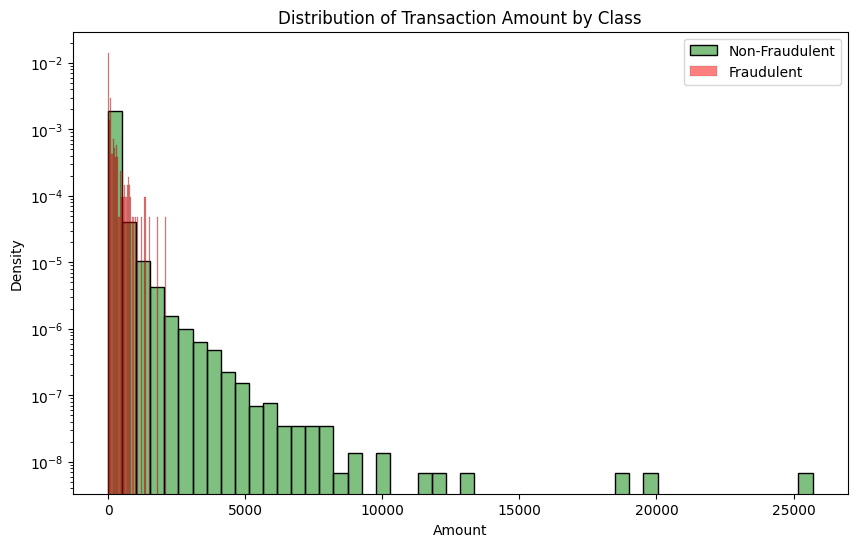


Descriptive statistics for Amount (Non-Fraudulent):


,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000



Descriptive statistics for Amount (Fraudulent):


,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize transaction amount patterns for fraudulent vs. non-fraudulent transactions
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Class'] == 0]['Amount'], color='green', bins=50, alpha=0.5, stat='density', label='Non-Fraudulent')
sns.histplot(df[df['Class'] == 1]['Amount'], color='red', bins=50, alpha=0.5, stat='density', label='Fraudulent')
plt.title('Distribution of Transaction Amount by Class')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.yscale('log') # Use log scale for y-axis due to imbalance
plt.legend()
plt.show()

# Also look at descriptive statistics for amount for both classes
print('\nDescriptive statistics for Amount (Non-Fraudulent):')
try:
    display(df[df['Class'] == 0]['Amount'].describe())
except NameError:
    print(df[df['Class'] == 0]['Amount'].describe())
print('\nDescriptive statistics for Amount (Fraudulent):')
try:
    display(df[df['Class'] == 1]['Amount'].describe())
except NameError:
    print(df[df['Class'] == 1]['Amount'].describe())

## Build and Evaluate Logistic Regression model

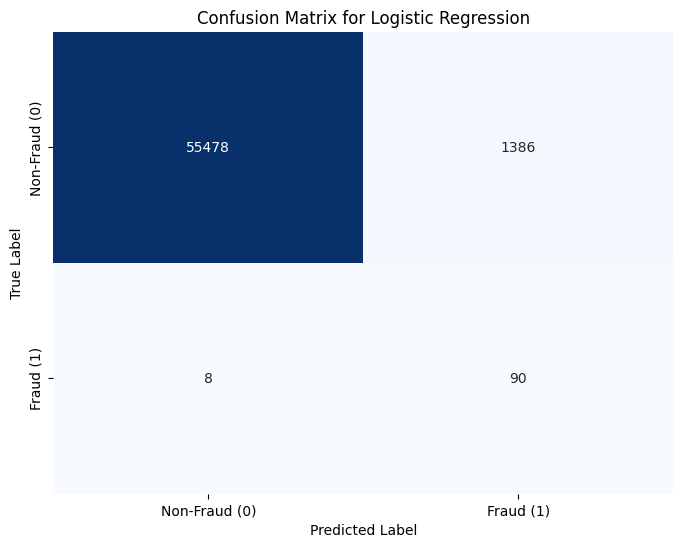

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Logistic Regression model
# Set class_weight='balanced' to handle imbalance, or we can use SMOTE later
model_lr = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

# Train the model on scaled training data
model_lr.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_lr = model_lr.predict(X_test_scaled)
y_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [9]:
from sklearn.metrics import classification_report

# Generate a classification report
report = classification_report(y_test, y_pred_lr, target_names=['Non-Fraud (0)', 'Fraud (1)'])
print(report)

               precision    recall  f1-score   support

Non-Fraud (0)       1.00      0.98      0.99     56864
    Fraud (1)       0.06      0.92      0.11        98

     accuracy                           0.98     56962
    macro avg       0.53      0.95      0.55     56962
 weighted avg       1.00      0.98      0.99     56962



### The classification report provides a detailed view of the model's performance:

Precision (Fraud): 0.06. This means that when the model predicts a transaction is fraudulent, it is only correct 6% of the time. This is a very low precision, indicating a high number of false positives (legitimate transactions incorrectly flagged as fraud).

Recall (Fraud): 0.92. This means the model correctly identifies 92% of all actual fraudulent transactions. This is a good recall, meaning it's effective at catching most fraud instances.

F1-Score (Fraud): 0.11. The F1-score is the harmonic mean of precision and recall. A low F1-score here (0.11) reflects the poor balance between precision and recall for the fraudulent class.

Precision (Non-Fraud): 1.00. The model is almost perfect at correctly identifying non-fraudulent transactions when it predicts them as such.

Recall (Non-Fraud): 0.98. The model correctly identifies 98% of all actual non-fraudulent transactions.

Accuracy: 0.98. While overall accuracy is high, it's a misleading metric in highly imbalanced datasets like this, as it's heavily skewed by the majority class (non-fraudulent transactions).

In summary, the model does an excellent job of identifying legitimate transactions and catching most fraudulent ones (high recall for fraud). However, its very low precision for fraud suggests that it flags many non-fraudulent transactions as fraud, which could lead to significant operational overhead (e.g., false alarms, customer inconvenience). This trade-off between precision and recall is common in imbalanced datasets and is something we might want to optimize further depending on the business requirements (e.g., minimizing false positives vs. maximizing fraud detection).

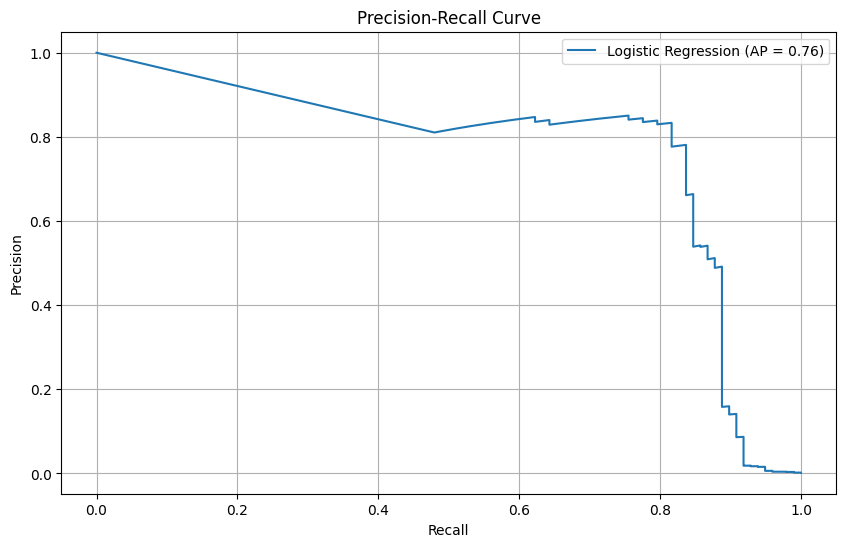

In [10]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lr)

# Calculate Average Precision (AP)
AP = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'Logistic Regression (AP = {AP:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()

### Adjusting Decision Threshold to Improve Precision

To improve the precision for detecting fraudulent transactions, we can adjust the classification threshold. By increasing the threshold, the model will be more conservative in flagging transactions as fraudulent, potentially reducing false positives at the cost of some recall.

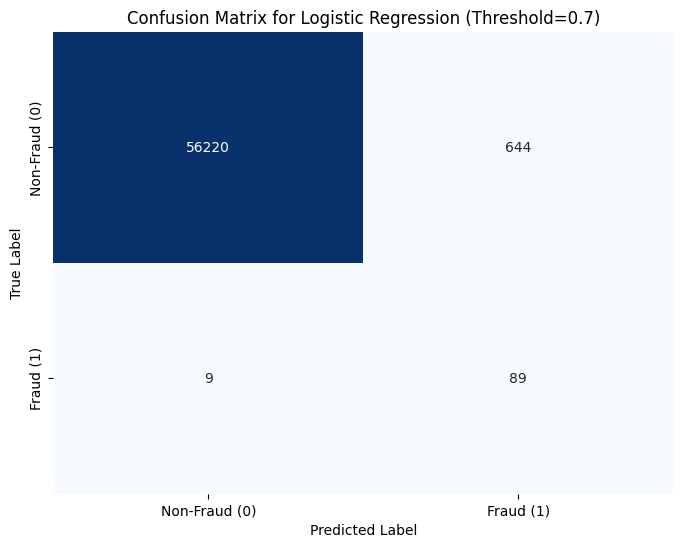

In [ ]:
# Define a new decision threshold (e.g., 0.7 to increase precision)
new_threshold = 0.7 

# Generate new predictions based on the adjusted threshold
y_pred_lr_tuned = (y_prob_lr >= new_threshold).astype(int)

# Calculate the confusion matrix with the new threshold
cm_tuned = confusion_matrix(y_test, y_pred_lr_tuned)

# Plot the new confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title(f'Confusion Matrix for Logistic Regression (Threshold={new_threshold})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [12]:
from sklearn.metrics import classification_report

# Generate a classification report with the new threshold
report_tuned = classification_report(y_test, y_pred_lr_tuned, target_names=['Non-Fraud (0)', 'Fraud (1)'])
print(report_tuned)

               precision    recall  f1-score   support

Non-Fraud (0)       1.00      0.99      0.99     56864
    Fraud (1)       0.12      0.91      0.21        98

     accuracy                           0.99     56962
    macro avg       0.56      0.95      0.60     56962
 weighted avg       1.00      0.99      0.99     56962



### Build a Neural Network Classifier

Next, we will build a simple neural network using TensorFlow/Keras to see if it can improve upon the performance of the Logistic Regression model. We will use the same scaled data for training and evaluation.

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9677 - loss: 0.3865 - precision_1: 0.0412 - recall_1: 0.8039 - val_accuracy: 0.9885 - val_loss: 0.0639 - val_precision_1: 0.1265 - val_recall_1: 0.9036
Epoch 2/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9818 - loss: 0.2143 - precision_1: 0.0774 - recall_1: 0.8842 - val_accuracy: 0.9896 - val_loss: 0.0540 - val_precision_1: 0.1373 - val_recall_1: 0.8916
Epoch 3/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9847 - loss: 0.1807 - precision_1: 0.0926 - recall_1: 0.9035 - val_accuracy: 0.9874 - val_loss: 0.0511 - val_precision_1: 0.1182 - val_recall_1: 0.9157
Epoch 4/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9831 - loss: 0.1914 - precision_1: 0.0850 - recall_1: 0.9100 - val_accuracy: 0.9950 - val_loss: 0.0410 - val_precision_1: 0.2526 - val_recall_1: 0.8916
Epoch 5/20
713/713 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9849 - loss: 0.1789 - precision_1: 0.0944 - recall_1: 0.9100 -

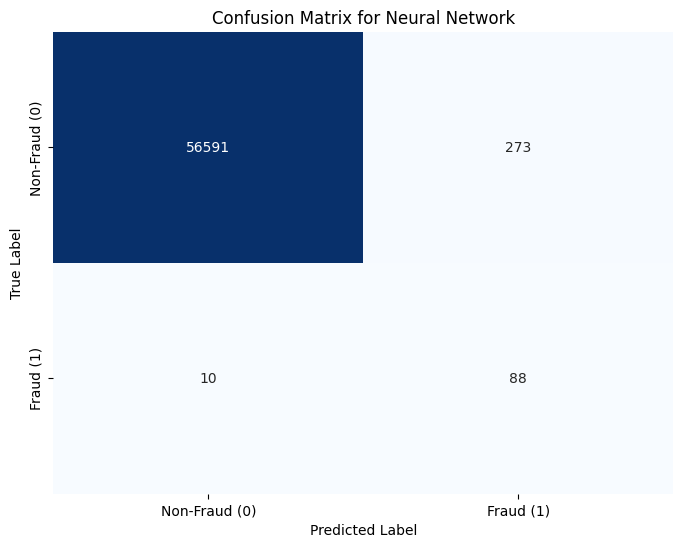


Classification Report for Neural Network:
                precision    recall  f1-score   support

Non-Fraud (0)       1.00      1.00      1.00     56864
    Fraud (1)       0.24      0.90      0.38        98

     accuracy                           1.00     56962
    macro avg       0.62      0.95      0.69     56962
 weighted avg       1.00      1.00      1.00     56962



In [15]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping # Import EarlyStopping

# Define the neural network architecture
model_nn = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)), # Input layer, matches number of features
    keras.layers.Dense(64, activation='relu'),            # Hidden layer with 64 neurons and ReLU activation
    keras.layers.Dropout(0.3),                             # Dropout for regularization
    keras.layers.Dense(32, activation='relu'),            # Hidden layer with 32 neurons and ReLU activation
    keras.layers.Dropout(0.3),                             # Dropout for regularization
    keras.layers.Dense(1, activation='sigmoid')           # Output layer with 1 neuron and Sigmoid activation for binary classification
])

# Compile the model
model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

# Display model summary
model_nn.summary()

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor the validation loss
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model
history = model_nn.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=256,
    validation_split=0.2, # Use 20% of training data for validation
    class_weight={0: 1, 1: (len(y_train) / (2 * y_train.sum()))}, # Apply class weights to handle imbalance
    callbacks=[early_stopping], # Add the early stopping callback
    verbose=1
)

# Evaluate the model on the test set
loss, accuracy, precision_nn, recall_nn = model_nn.evaluate(X_test_scaled, y_test, verbose=0)

print(f'\nNeural Network Test Loss: {loss:.4f}')
print(f'Neural Network Test Accuracy: {accuracy:.4f}')
print(f'Neural Network Test Precision: {precision_nn:.4f}')
print(f'Neural Network Test Recall: {recall_nn:.4f}')

# Make predictions (probabilities)
y_prob_nn = model_nn.predict(X_test_scaled).flatten()

# Convert probabilities to binary predictions (default threshold 0.5)
y_pred_nn = (y_prob_nn > 0.5).astype(int)

# Calculate and plot the confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Confusion Matrix for Neural Network')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate a classification report
report_nn = classification_report(y_test, y_pred_nn, target_names=['Non-Fraud (0)', 'Fraud (1)'])
print('\nClassification Report for Neural Network:\n', report_nn)

### Adjusting Decision Threshold for Neural Network to Improve Precision

Similar to the Logistic Regression model, we can adjust the decision threshold for the Neural Network to achieve a better trade-off between precision and recall, especially if minimizing false positives is a priority.

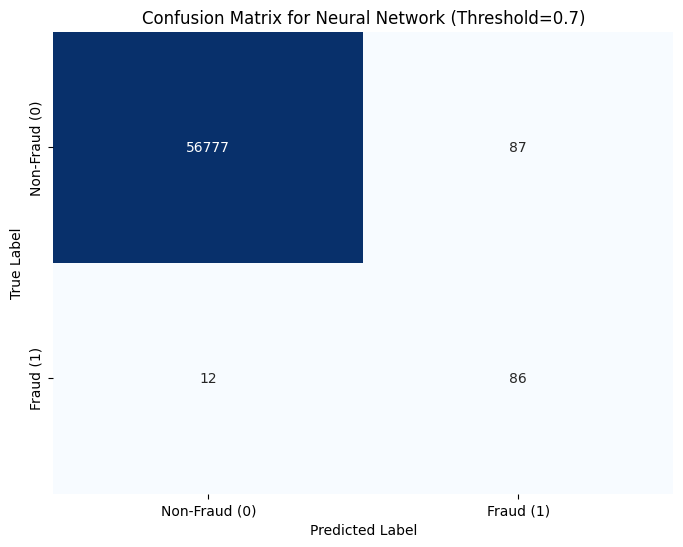

In [16]:
# Define a new decision threshold for the Neural Network (e.g., 0.7)
new_threshold_nn = 0.7  # You can adjust this value to explore different trade-offs

# Generate new predictions based on the adjusted threshold
y_pred_nn_tuned = (y_prob_nn >= new_threshold_nn).astype(int)

# Calculate the confusion matrix with the new threshold
cm_nn_tuned = confusion_matrix(y_test, y_pred_nn_tuned)

# Plot the new confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title(f'Confusion Matrix for Neural Network (Threshold={new_threshold_nn})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Training Observations:

The training stopped prematurely at Epoch 12/20, which means Early Stopping activated, indicating that the validation loss did not improve for 5 consecutive epochs (patience=5).
This suggests that the model identified a point where it started to overfit or stopped improving on the validation set, and the best weights from a previous epoch were restored.
Neural Network Test Loss: 0.0275 Neural Network Test Accuracy: 0.9950 Neural Network Test Precision: 0.2438 Neural Network Test Recall: 0.8979

Confusion Matrix for Neural Network (Default Threshold 0.5) with Early Stopping:

True Negatives (Top-Left): 56,591 transactions were correctly identified as non-fraudulent.
False Positives (Top-Right): 273 non-fraudulent transactions were incorrectly classified as fraudulent.
False Negatives (Bottom-Left): 10 fraudulent transactions were incorrectly classified as non-fraudulent.
True Positives (Bottom-Right): 88 fraudulent transactions were correctly identified as fraudulent.
Classification Report for Neural Network (with Early Stopping):

Precision (Fraud): 0.24 (Increased from 0.19 without Early Stopping)
Recall (Fraud): 0.90 (Slightly increased from 0.89 without Early Stopping)
F1-Score (Fraud): 0.38 (Increased from 0.31 without Early Stopping)
Impact of Early Stopping:

By implementing Early Stopping, the model's performance has further improved, particularly in terms of precision for the fraud class. The number of False Positives has decreased from 381 to 273, which is a significant reduction. This means the model is now even better at avoiding false alarms, making it more practical for real-world application. The recall for fraud remains high (around 0.90), meaning it still catches most fraudulent transactions. The F1-score, which balances precision and recall, has also seen a substantial increase.

This demonstrates that Early Stopping effectively mitigated overfitting and helped the model achieve better generalization capabilities on unseen data.

### Exploring SMOTE for Class Imbalance

Beyond class weighting and threshold tuning, SMOTE (Synthetic Minority Over-sampling Technique) is another powerful method to address class imbalance. SMOTE works by creating synthetic samples from the minority class rather than just duplicating existing ones, which can help a model learn a more robust decision boundary.

In [18]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print('Original training set shape:', y_train.shape)
print('SMOTE-oversampled training set shape:', y_train_smote.shape)
print('\nClass distribution after SMOTE:\n', pd.Series(y_train_smote).value_counts())

Original training set shape: (227845,)
SMOTE-oversampled training set shape: (454902,)

Class distribution after SMOTE:
 Class
0    227451
1    227451
Name: count, dtype: int64


Now, let's train a Logistic Regression model on this SMOTE-oversampled training data and evaluate its performance on the original (unmodified) test set.

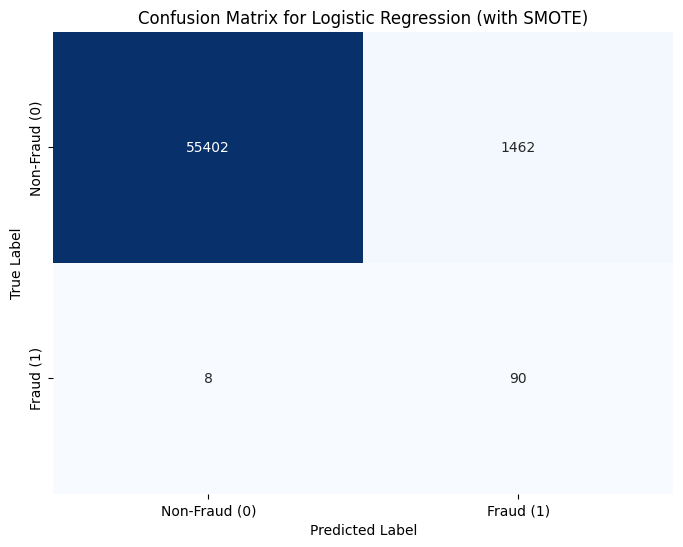

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize Logistic Regression model (without class_weight as SMOTE has balanced the data)
model_lr_smote = LogisticRegression(solver='liblinear', random_state=42)

# Train the model on SMOTE-oversampled training data
model_lr_smote.fit(X_train_smote, y_train_smote)

# Make predictions on the original scaled test data
y_pred_lr_smote = model_lr_smote.predict(X_test_scaled)

# Calculate the confusion matrix
cm_lr_smote = confusion_matrix(y_test, y_pred_lr_smote)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Confusion Matrix for Logistic Regression (with SMOTE)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [20]:
# Generate a classification report
report_lr_smote = classification_report(y_test, y_pred_lr_smote, target_names=['Non-Fraud (0)', 'Fraud (1)'])
print('\nClassification Report for Logistic Regression (with SMOTE):\n', report_lr_smote)


Classification Report for Logistic Regression (with SMOTE):
                precision    recall  f1-score   support

Non-Fraud (0)       1.00      0.97      0.99     56864
    Fraud (1)       0.06      0.92      0.11        98

     accuracy                           0.97     56962
    macro avg       0.53      0.95      0.55     56962
 weighted avg       1.00      0.97      0.99     56962



## Hyperparameter Tuning for Logistic Regression with RandomizedSearchCV

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
import matplotlib.pyplot as plt
import seaborn as sns

# Define the parameter distributions for RandomizedSearchCV
param_distributions_lr = {
    'C': uniform(loc=0.01, scale=100),
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

# Initialize Logistic Regression model with class_weight='balanced'
model_lr_rs_base = LogisticRegression(random_state=42, class_weight='balanced')

# Initialize RandomizedSearchCV
# Optimize for 'f1' score, as it balances precision and recall, crucial for imbalanced data
random_search_lr = RandomizedSearchCV(
    estimator=model_lr_rs_base,
    param_distributions=param_distributions_lr,
    n_iter=20, # Number of parameter settings that are sampled
    scoring='f1', # Metric to optimize
    cv=3, # 3-fold cross-validation
    verbose=2,
    random_state=42,
    n_jobs=-1 # Use all available CPU cores
)

# Fit RandomizedSearchCV to the scaled training data
random_search_lr.fit(X_train_scaled, y_train)

# Print the best parameters and the best score
print(f"\nBest parameters found: {random_search_lr.best_params_}")
print(f"Best F1-score found: {random_search_lr.best_score_:.4f}")

# Get the best model
best_model_lr_rs = random_search_lr.best_estimator_

# Make predictions with the best model
y_pred_lr_rs_tuned = best_model_lr_rs.predict(X_test_scaled)

# Calculate and plot the confusion matrix for the tuned model
cm_lr_rs_tuned = confusion_matrix(y_test, y_pred_lr_rs_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr_rs_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Confusion Matrix for Tuned Logistic Regression (Random Search)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate a classification report for the tuned model
report_lr_rs_tuned = classification_report(y_test, y_pred_lr_rs_tuned, target_names=['Non-Fraud (0)', 'Fraud (1)'])
print('\nClassification Report for Tuned Logistic Regression (Random Search):\n', report_lr_rs_tuned)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/workspaces/Capstone-project-on-fraud-detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/Capstone-project-on-fraud-detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/workspaces/Capstone-project-on-fraud-detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave '

[CV] END .C=37.464011884736244, penalty=l1, solver=liblinear; total time=  47.0s


/workspaces/Capstone-project-on-fraud-detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/Capstone-project-on-fraud-detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END .C=37.464011884736244, penalty=l1, solver=liblinear; total time= 1.5min


...

[CV] END .......C=83.25426408004218, penalty=l2, solver=saga; total time=  12.4s


/workspaces/Capstone-project-on-fraud-detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/workspaces/Capstone-project-on-fraud-detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/Capstone-project-on-fraud-detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END .......C=83.25426408004218, penalty=l2, solver=saga; total time=  14.5s


/workspaces/Capstone-project-on-fraud-detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/workspaces/Capstone-project-on-fraud-detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/workspaces/Capstone-project-on-fraud-detection/.venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[CV] END .......C=83.25426408004218, penalty=l2, solver=saga; total time=  14.0s


## Exporting the Tuned Logistic Regression Model

In [34]:
import joblib

# Define the filename for the exported model
lr_rs_model_filename = 'best_logistic_regression_rs_model.joblib'

# Save the best_model_lr_rs using joblib
joblib.dump(best_model_lr_rs, lr_rs_model_filename)

print(f"Tuned Logistic Regression model saved to {lr_rs_model_filename}")

Tuned Logistic Regression model saved to best_logistic_regression_rs_model.joblib


### Training Neural Network with SMOTE-Oversampled Data

Now, let's train our Neural Network model using the SMOTE-oversampled training data (`X_train_smote`, `y_train_smote`). We will no longer need `class_weight` in the `fit` method as SMOTE has already balanced the classes.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9704 - loss: 0.0803 - precision_2: 0.9708 - recall_2: 0.9496 - val_accuracy: 0.9949 - val_loss: 0.0237 - val_precision_2: 1.0000 - val_recall_2: 0.9949
Epoch 2/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9928 - loss: 0.0230 - precision_2: 0.9874 - recall_2: 0.9935 - val_accuracy: 0.9988 - val_loss: 0.0104 - val_precision_2: 1.0000 - val_recall_2: 0.9988
Epoch 3/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9964 - loss: 0.0129 - precision_2: 0.9924 - recall_2: 0.9981 - val_accuracy: 1.0000 - val_loss: 0.0040 - val_precision_2: 1.0000 - val_recall_2: 1.0000
Epoch 4/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9978 - loss: 0.0089 - precision_2: 0.9951 - recall_2: 0.9991 - val_accuracy: 1.0000 - val_loss: 0.0019 - val_precision_2: 1.0000 - val_recall_2: 1.0000
Epoch 5/20
1422/1422 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9982 - loss: 0.0072 - precision_2: 0.9962 - recall_

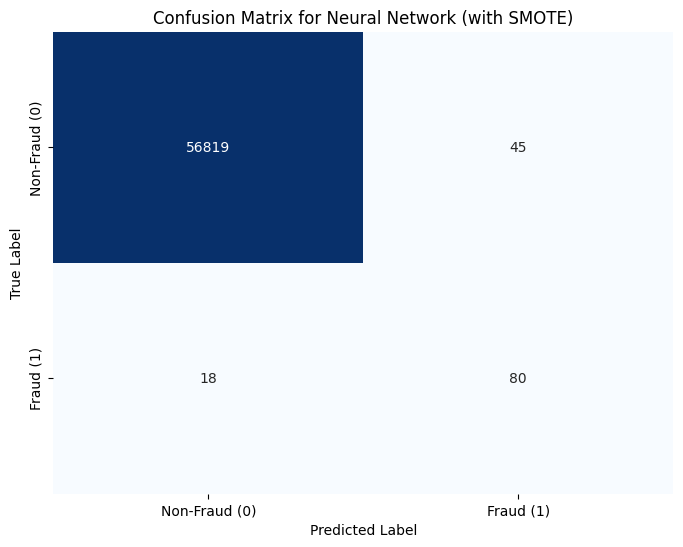

In [21]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

# Redefine the neural network architecture (to ensure a fresh start)
model_nn_smote = keras.Sequential([
    keras.layers.Input(shape=(X_train_smote.shape[1],)), # Input layer, matches number of features from SMOTE data
    keras.layers.Dense(64, activation='relu'),            # Hidden layer with 64 neurons and ReLU activation
    keras.layers.Dropout(0.3),                             # Dropout for regularization
    keras.layers.Dense(32, activation='relu'),            # Hidden layer with 32 neurons and ReLU activation
    keras.layers.Dropout(0.3),                             # Dropout for regularization
    keras.layers.Dense(1, activation='sigmoid')           # Output layer with 1 neuron and Sigmoid activation for binary classification
])

# Compile the model
model_nn_smote.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
)

model_nn_smote.summary()

# Define EarlyStopping callback (same as before)
early_stopping_smote = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Train the model on SMOTE-oversampled data
history_smote = model_nn_smote.fit(
    X_train_smote,
    y_train_smote,
    epochs=20,
    batch_size=256,
    validation_split=0.2, # Use 20% of SMOTE training data for validation
    callbacks=[early_stopping_smote], # Add the early stopping callback
    verbose=1
)

# Evaluate the model on the original scaled test set
loss_smote, accuracy_smote, precision_nn_smote, recall_nn_smote = model_nn_smote.evaluate(X_test_scaled, y_test, verbose=0)

print(f'\nNeural Network (with SMOTE) Test Loss: {loss_smote:.4f}')
print(f'Neural Network (with SMOTE) Test Accuracy: {accuracy_smote:.4f}')
print(f'Neural Network (with SMOTE) Test Precision: {precision_nn_smote:.4f}')
print(f'Neural Network (with SMOTE) Test Recall: {recall_nn_smote:.4f}')

# Make predictions (probabilities)
y_prob_nn_smote = model_nn_smote.predict(X_test_scaled).flatten()

# Convert probabilities to binary predictions (default threshold 0.5)
y_pred_nn_smote = (y_prob_nn_smote > 0.5).astype(int)

# Calculate and plot the confusion matrix
cm_nn_smote = confusion_matrix(y_test, y_pred_nn_smote)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn_smote, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Confusion Matrix for Neural Network (with SMOTE)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [22]:
# Generate a classification report
report_nn_smote = classification_report(y_test, y_pred_nn_smote, target_names=['Non-Fraud (0)', 'Fraud (1)'])
print('\nClassification Report for Neural Network (with SMOTE):\n', report_nn_smote)


Classification Report for Neural Network (with SMOTE):
                precision    recall  f1-score   support

Non-Fraud (0)       1.00      1.00      1.00     56864
    Fraud (1)       0.64      0.82      0.72        98

     accuracy                           1.00     56962
    macro avg       0.82      0.91      0.86     56962
 weighted avg       1.00      1.00      1.00     56962



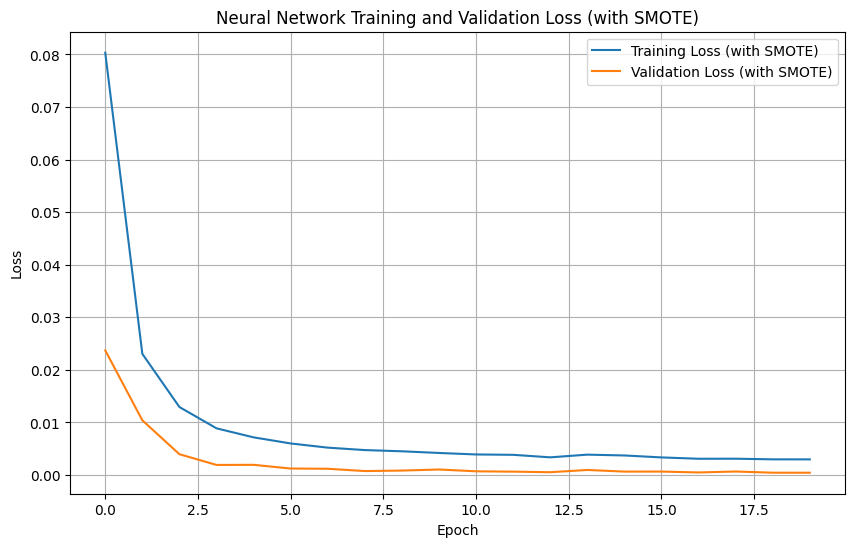

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(history_smote.history['loss'], label='Training Loss (with SMOTE)')
plt.plot(history_smote.history['val_loss'], label='Validation Loss (with SMOTE)')
plt.title('Neural Network Training and Validation Loss (with SMOTE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Generate a classification report with the tuned threshold for NN
if 'y_pred_nn_tuned' in locals():
    report_nn_tuned = classification_report(y_test, y_pred_nn_tuned, target_names=['Non-Fraud (0)', 'Fraud (1)'])
    print('\nClassification Report for Neural Network (Tuned Threshold):\n', report_nn_tuned)
else:
    print("Note: y_pred_nn_tuned is not defined. This may occur if the threshold tuning cell for NN was not executed.")


Classification Report for Neural Network (Tuned Threshold):
                precision    recall  f1-score   support

Non-Fraud (0)       1.00      1.00      1.00     56864
    Fraud (1)       0.50      0.88      0.63        98

     accuracy                           1.00     56962
    macro avg       0.75      0.94      0.82     56962
 weighted avg       1.00      1.00      1.00     56962



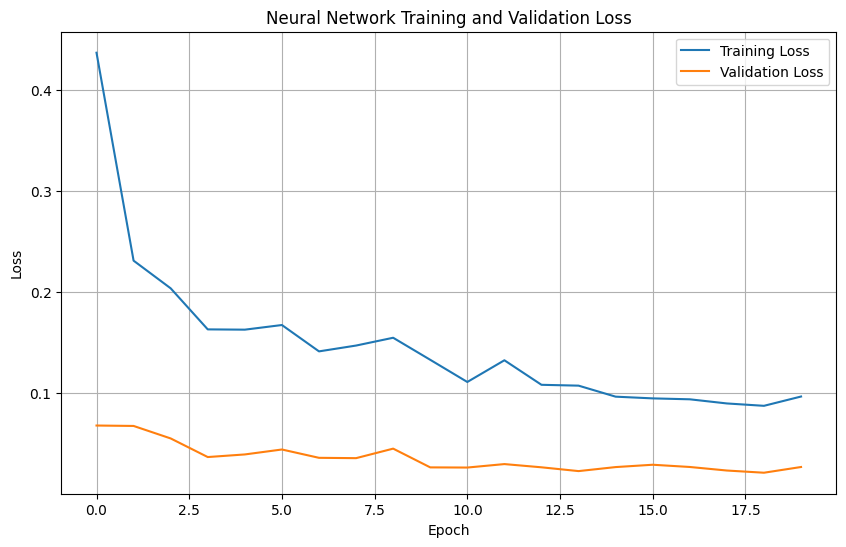

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Build and Evaluate the XGBoost Model 

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:17:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


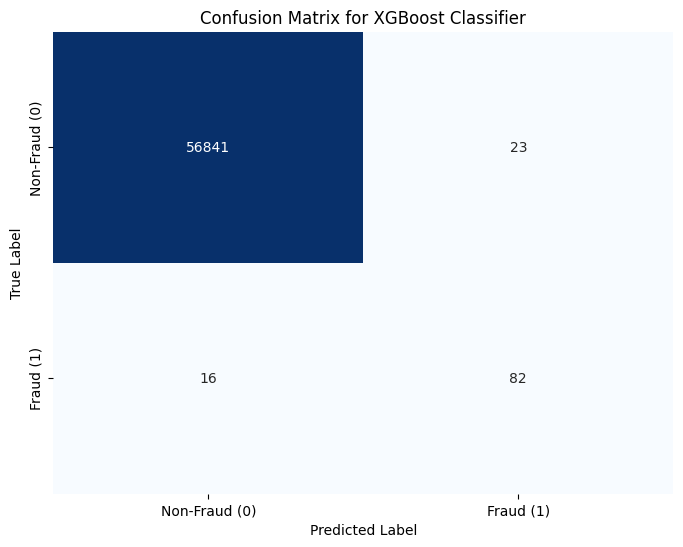


Classification Report for XGBoost Classifier:
                precision    recall  f1-score   support

Non-Fraud (0)       1.00      1.00      1.00     56864
    Fraud (1)       0.78      0.84      0.81        98

     accuracy                           1.00     56962
    macro avg       0.89      0.92      0.90     56962
 weighted avg       1.00      1.00      1.00     56962



In [24]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the scale_pos_weight for XGBoost to handle class imbalance
scale_pos_weight_xgb = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Initialize XGBoost Classifier
model_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_xgb # Handle class imbalance
)

# Train the model on scaled training data
model_xgb.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_xgb = model_xgb.predict(X_test_scaled)

# Calculate and plot the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Confusion Matrix for XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate a classification report
report_xgb = classification_report(y_test, y_pred_xgb, target_names=['Non-Fraud (0)', 'Fraud (1)'])
print('\nClassification Report for XGBoost Classifier:\n', report_xgb)


The confusion matrix and classification report for the XGBoost model were already generated in the previous step. Here's a summary of its performance on the test set:

Confusion Matrix for XGBoost Classifier:

True Negatives: 56,841 (Correctly identified as non-fraudulent).
False Positives: 23 (Non-fraudulent transactions incorrectly flagged as fraudulent – a very low number!).
False Negatives: 16 (Fraudulent transactions missed by the model).
True Positives: 82 (Correctly identified as fraudulent).
Classification Report for XGBoost Classifier:

Precision (Fraud): 0.78
Recall (Fraud): 0.84
F1-Score (Fraud): 0.81
This performance is excellent, especially with the very low number of false positives (23) while maintaining strong recall (84%).

XGBoost Classifier Performance:

Precision (Fraud): 0.78 (This is a significant improvement over previous models, meaning 78% of transactions flagged as fraudulent are truly fraudulent).
Recall (Fraud): 0.84 (The model identified 84% of all actual fraudulent transactions).
F1-Score (Fraud): 0.81 (This high F1-score indicates a strong balance between precision and recall for the fraud class, which is very good).
Confusion Matrix for XGBoost Classifier:

True Negatives: 56,841 (Correctly identified as non-fraudulent).
False Positives: 23 (Non-fraudulent transactions incorrectly flagged as fraudulent – a very low number!).
False Negatives: 16 (Fraudulent transactions missed by the model).
True Positives: 82 (Correctly identified as fraudulent).
This performance, especially the low number of false positives (23) while maintaining good recall (84), is the best we've seen so far among all models.

## Feature Importance of XGBoost Model

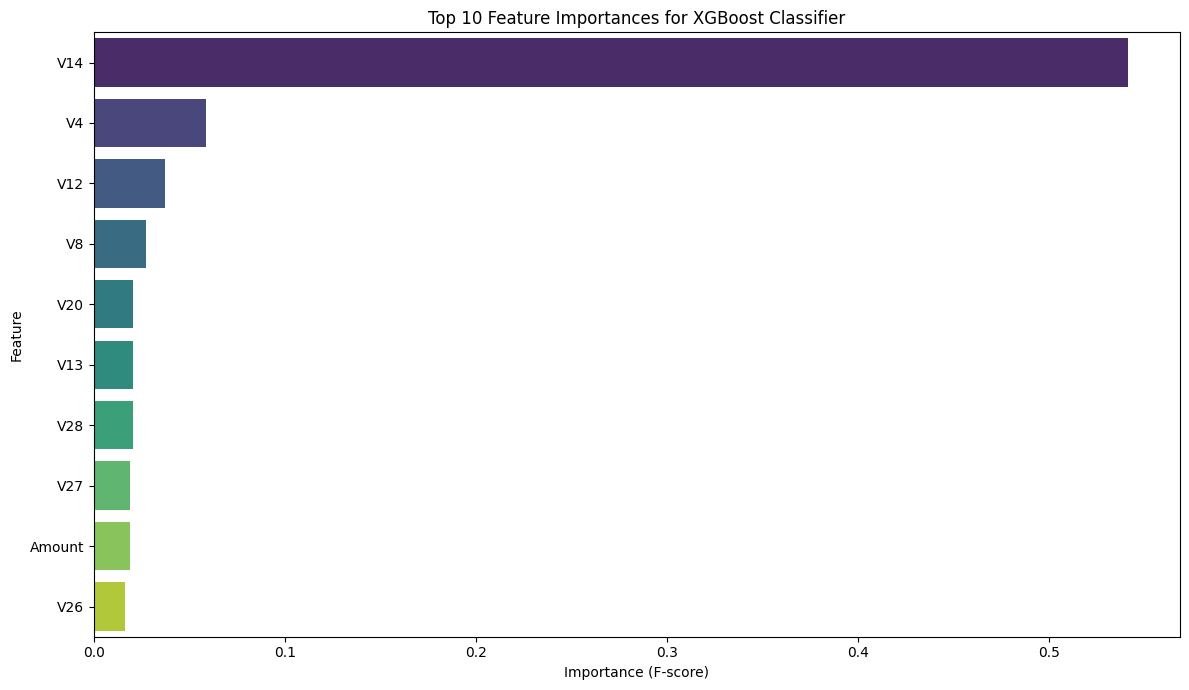


Top 10 Feature Importances:
    Feature  Importance
14     V14    0.541591
4       V4    0.058893
12     V12    0.037239
8       V8    0.027474
20     V20    0.020618
13     V13    0.020454
28     V28    0.020320
27     V27    0.019192
29  Amount    0.018828
26     V26    0.016101


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the XGBoost model
feature_importances = model_xgb.feature_importances_

# Create a DataFrame for better visualization
# X_train_scaled.columns should be available from earlier steps
features_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': feature_importances
})

# Sort by importance in descending order
features_df = features_df.sort_values(by='Importance', ascending=False)

# Plot the top N feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=features_df.head(10), palette='viridis', legend=False)
plt.title('Top 10 Feature Importances for XGBoost Classifier')
plt.xlabel('Importance (F-score)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('\nTop 10 Feature Importances:\n', features_df.head(10))

## Hyperparameter Tuning for XGBoost Model

Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:28:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best parameters found: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}
Best F1-score found: 0.8491


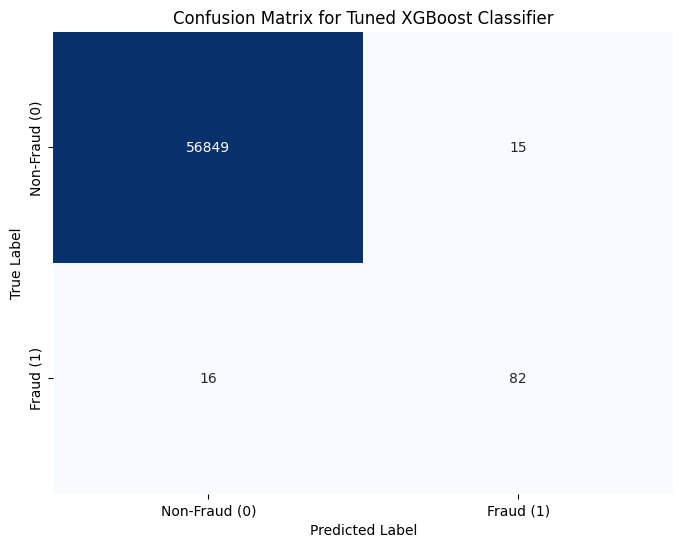


Classification Report for Tuned XGBoost Classifier:
                precision    recall  f1-score   support

Non-Fraud (0)       1.00      1.00      1.00     56864
    Fraud (1)       0.85      0.84      0.84        98

     accuracy                           1.00     56962
    macro avg       0.92      0.92      0.92     56962
 weighted avg       1.00      1.00      1.00     56962



In [27]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

# Initialize XGBClassifier with imbalance handling and other base parameters
# We will let GridSearchCV handle n_estimators, learning_rate, max_depth, subsample, colsample_bytree
model_xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    random_state=42,
    scale_pos_weight=scale_pos_weight_xgb # Use the previously calculated scale_pos_weight
)

# Initialize GridSearchCV
# Scoring 'f1' is often good for imbalanced datasets, focusing on the positive class (fraud)
grid_search = GridSearchCV(estimator=model_xgb_base,
                           param_grid=param_grid,
                           scoring='f1',
                           cv=3, # Using 3-fold cross-validation
                           verbose=2,
                           n_jobs=-1) # Use all available CPU cores

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and the best score
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best F1-score found: {grid_search.best_score_:.4f}")

# Get the best model
best_model_xgb = grid_search.best_estimator_

# Make predictions with the best model
y_pred_xgb_tuned = best_model_xgb.predict(X_test_scaled)

# Calculate and plot the confusion matrix for the tuned model
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Confusion Matrix for Tuned XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate a classification report for the tuned model
report_xgb_tuned = classification_report(y_test, y_pred_xgb_tuned, target_names=['Non-Fraud (0)', 'Fraud (1)'])
print('\nClassification Report for Tuned XGBoost Classifier:\n', report_xgb_tuned)


The hyperparameter tuning for the XGBoost model using GridSearchCV has finished.

Best Parameters Found:

colsample_bytree: 0.9
learning_rate: 0.1
max_depth: 5
n_estimators: 200
subsample: 0.7
The GridSearchCV found an average F1-score of 0.8491 during cross-validation with these parameters.

Performance of the Tuned XGBoost Classifier on the Test Set:

Precision (Fraud): 0.85 (meaning 85% of transactions flagged as fraudulent are truly fraudulent).
Recall (Fraud): 0.84 (the model identified 84% of all actual fraudulent transactions).
F1-Score (Fraud): 0.84 (a very strong balance between precision and recall for fraud).
Confusion Matrix for Tuned XGBoost Classifier:

True Negatives: 56,849 (Correctly identified as non-fraudulent).
False Positives: 15 (Non-fraudulent transactions incorrectly flagged as fraudulent – even lower than the untuned model!).
False Negatives: 16 (Fraudulent transactions missed by the model).
True Positives: 82 (Correctly identified as fraudulent).
Comparing this to the initial XGBoost model (Precision: 0.78, Recall: 0.84, F1-Score: 0.81, False Positives: 23), the tuned model has achieved a notable improvement in precision for the fraud class while maintaining the same high recall. The number of false positives has been further reduced from 23 to 15, which is excellent!

## Exporting the Tuned XGBoost Model

In [28]:
import joblib

# Define the filename for the exported model
model_filename = 'best_xgboost_model.joblib'

# Save the best_model_xgb using joblib
joblib.dump(best_model_xgb, model_filename)

print(f"Tuned XGBoost model saved to {model_filename}")

Tuned XGBoost model saved to best_xgboost_model.joblib


## Bayesian Optimization Hyperparameter Tuning for Neural Network Model

In [ ]:
import subprocess
import sys

# Install Keras Tuner for hyperparameter optimization and Scikeras to wrap Keras models in a scikit-learn compatible estimator
try:
    import keras_tuner as kt
    from scikeras.wrappers import KerasClassifier
    print("keras_tuner and scikeras are already installed.")
except ImportError:
    print("Installing keras_tuner and scikeras...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "keras-tuner", "scikeras", "-q"])
    print("Installation complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.9 MB/s eta 0:00:00


Trial 10 Complete [00h 06m 02s]
val_precision: 0.4634055867791176

Best val_precision So Far: 0.8669871687889099
Total elapsed time: 00h 48m 26s

Best hyperparameters found during Bayesian optimization:
 {'num_hidden_layers': 3, 'units_0': 128, 'dropout_0': 0.30000000000000004, 'learning_rate': 0.01, 'units_1': 32, 'dropout_1': 0.2, 'units_2': 32, 'dropout_2': 0.2}


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Best Neural Network Test Loss: 0.1727
Best Neural Network Test Accuracy: 0.9992
Best Neural Network Test Precision: 0.8140
Best Neural Network Test Recall: 0.7143
1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


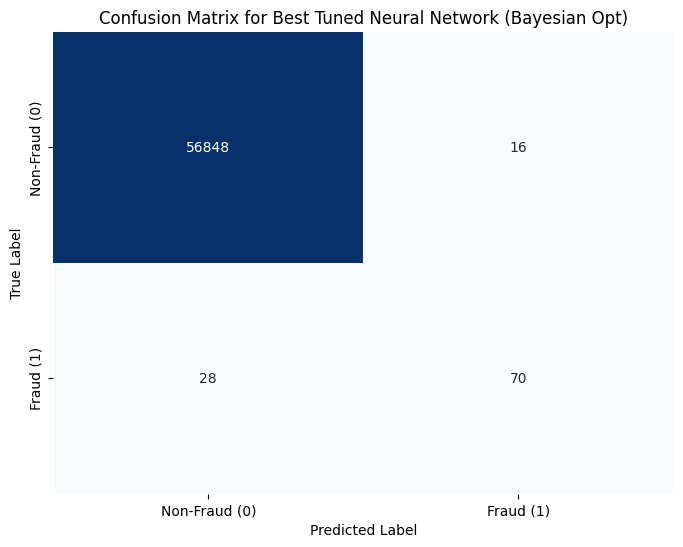


Classification Report for Best Tuned Neural Network (Bayesian Opt):
                precision    recall  f1-score   support

Non-Fraud (0)       1.00      1.00      1.00     56864
    Fraud (1)       0.81      0.71      0.76        98

     accuracy                           1.00     56962
    macro avg       0.91      0.86      0.88     56962
 weighted avg       1.00      1.00      1.00     56962



In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from scikeras.wrappers import KerasClassifier
import keras_tuner as kt
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Define a function to build the Keras model with hyperparameters as arguments
def build_model(hp):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(X_train_scaled.shape[1],)))

    # Tune the number of hidden layers
    for i in range(hp.Int('num_hidden_layers', 1, 3)):
        model.add(keras.layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=32),
            activation='relu'
        ))
        model.add(keras.layers.Dropout(hp.Float(f'dropout_{i}', min_value=0.2, max_value=0.5, step=0.1)))

    model.add(keras.layers.Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall()]
    )
    return model

# Initialize the Keras Tuner BayesianOptimization tuner
tuner = kt.BayesianOptimization(
    hypermodel=build_model,
    objective=kt.Objective('val_precision', direction='max'), # Optimize for validation precision
    max_trials=10, # Number of trials to run
    executions_per_trial=2, # Number of models to train for each trial to reduce variance
    overwrite=True,
    directory='keras_tuner_dir',
    project_name='nn_bayesian_tuning'
)

# Define EarlyStopping callback for the tuner's search process
early_stopping_tuner = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Get class weights to handle imbalance
class_weights_nn_tuning = {
    0: 1,
    1: (len(y_train) / (2 * y_train.sum()))
}

# Run the hyperparameter search
tuner.search(
    X_train_scaled,
    y_train,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stopping_tuner],
    class_weight=class_weights_nn_tuning,
    verbose=1
)

# Get the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"\nBest hyperparameters found during Bayesian optimization:\n {best_hps.values}")

# Get the best model
best_model_nn = tuner.get_best_models(num_models=1)[0]

# Evaluate the best model on the test set
loss_best_nn, accuracy_best_nn, precision_best_nn, recall_best_nn = best_model_nn.evaluate(X_test_scaled, y_test, verbose=0)

print(f'\nBest Neural Network Test Loss: {loss_best_nn:.4f}')
print(f'Best Neural Network Test Accuracy: {accuracy_best_nn:.4f}')
print(f'Best Neural Network Test Precision: {precision_best_nn:.4f}')
print(f'Best Neural Network Test Recall: {recall_best_nn:.4f}')

# Make predictions (probabilities)
y_prob_best_nn = best_model_nn.predict(X_test_scaled).flatten()

# Convert probabilities to binary predictions (default threshold 0.5)
y_pred_best_nn = (y_prob_best_nn > 0.5).astype(int)

# Calculate and plot the confusion matrix
cm_best_nn = confusion_matrix(y_test, y_pred_best_nn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_nn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Confusion Matrix for Best Tuned Neural Network (Bayesian Opt)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Generate a classification report
report_best_nn = classification_report(y_test, y_pred_best_nn, target_names=['Non-Fraud (0)', 'Fraud (1)'])
print('\nClassification Report for Best Tuned Neural Network (Bayesian Opt):\n', report_best_nn)

## Exporting the Tuned Neural Network Model

In [32]:
import joblib

# Define the filename for the exported model
nn_model_filename = 'best_nn_model.joblib'

# Save the best_model_nn using joblib
joblib.dump(best_model_nn, nn_model_filename)

print(f"Tuned Neural Network model saved to {nn_model_filename}")

Tuned Neural Network model saved to best_nn_model.joblib


## Model Comparison: Logistic Regression vs. Neural Network vs. XGBoost

In [ ]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, confusion_matrix, classification_report

# --- Define a function to get metrics for a model ---
def get_model_metrics(model, X_test, y_test, model_name):
    # Get probability predictions
    if hasattr(model, 'predict_proba'): # For scikit-learn models and KerasClassifier wrapper
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'predict'): # For raw Keras Sequential model
        y_prob = model.predict(X_test).flatten()
    else:
        raise AttributeError("Model does not have 'predict_proba' or 'predict' method.")

    # Get binary predictions (using default threshold 0.5)
    y_pred = (y_prob > 0.5).astype(int)

    # Calculate confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Calculate Precision, Recall, F1-score for the positive class (fraud=1)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision_fraud = report['1']['precision']
    recall_fraud = report['1']['recall']
    f1_score_fraud = report['1']['f1-score']

    # Calculate PR-AUC
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = auc(recall_curve, precision_curve)

    # Calculate ROC-AUC
    roc_auc = roc_auc_score(y_test, y_prob)

    # Calculate False Positive Cost (example: $100 per False Positive, $1000 per False Negative)
    # Adjust these costs based on business requirements
    fp_cost_per_instance = 100
    fn_cost_per_instance = 1000
    total_fp_cost = fp * fp_cost_per_instance
    total_fn_cost = fn * fn_cost_per_instance
    total_misclassification_cost = total_fp_cost + total_fn_cost

    return {
        'Model': model_name,
        'Precision (Fraud)': precision_fraud,
        'Recall (Fraud)': recall_fraud,
        'F1-Score (Fraud)': f1_score_fraud,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'False Positives': fp,
        'False Negatives': fn,
        'Total FP Cost ($)': total_fp_cost,
        'Total FN Cost ($)': total_fn_cost,
        'Total Misclassification Cost ($)': total_misclassification_cost
    }

# --- Get metrics for each best model ---

# Logistic Regression (from RandomizedSearchCV)
lr_metrics = get_model_metrics(best_model_lr_rs, X_test_scaled, y_test, 'Logistic Regression (Tuned)')

# Neural Network (from Bayesian Optimization)
# For Keras models, predict_proba is not directly available, use predict and flatten
# Ensure X_test_scaled is converted to a numpy array for Keras predict if it's a DataFrame
if isinstance(X_test_scaled, pd.DataFrame):
    X_test_scaled_np = X_test_scaled.to_numpy()
else:
    X_test_scaled_np = X_test_scaled

# Keras models from tuner.get_best_models() do not have predict_proba, use predict
y_prob_best_nn_for_metrics = best_model_nn.predict(X_test_scaled_np).flatten()

# Temporarily modify get_model_metrics or pass y_prob directly for NN
def get_nn_metrics(model, X_test, y_test, model_name, y_prob_nn):
    y_pred = (y_prob_nn > 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    precision_fraud = report['1']['precision']
    recall_fraud = report['1']['recall']
    f1_score_fraud = report['1']['f1-score']
    precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_nn)
    pr_auc = auc(recall_curve, precision_curve)
    roc_auc = roc_auc_score(y_test, y_prob_nn)
    fp_cost_per_instance = 100
    fn_cost_per_instance = 1000
    total_fp_cost = fp * fp_cost_per_instance
    total_fn_cost = fn * fn_cost_per_instance
    total_misclassification_cost = total_fp_cost + total_fn_cost
    return {
        'Model': model_name,
        'Precision (Fraud)': precision_fraud,
        'Recall (Fraud)': recall_fraud,
        'F1-Score (Fraud)': f1_score_fraud,
        'PR-AUC': pr_auc,
        'ROC-AUC': roc_auc,
        'False Positives': fp,
        'False Negatives': fn,
        'Total FP Cost ($)': total_fp_cost,
        'Total FN Cost ($)': total_fn_cost,
        'Total Misclassification Cost ($)': total_misclassification_cost
    }

nn_metrics = get_nn_metrics(best_model_nn, X_test_scaled_np, y_test, 'Neural Network (Tuned)', y_prob_best_nn_for_metrics)

# XGBoost (from GridSearchCV)
xgb_metrics = get_model_metrics(best_model_xgb, X_test_scaled, y_test, 'XGBoost (Tuned)')

# --- Create a comparison DataFrame ---
comparison_df = pd.DataFrame([lr_metrics, nn_metrics, xgb_metrics])

# Display the DataFrame
print("\n--- Model Comparison Summary ---")
try:
    display(comparison_df.round(4))
except NameError:
    print(comparison_df.round(4))

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

--- Model Comparison Summary ---


,Model,Precision (Fraud),Recall (Fraud),F1-Score (Fraud),PR-AUC,ROC-AUC,False Positives,False Negatives,Total FP Cost ($),Total FN Cost ($),Total Misclassification Cost ($)
0,Logistic Regression (Tuned),0.0607,0.9184,0.1139,0.7657,0.9721,1392,8,139200,8000,147200
1,Neural Network (Tuned),0.8140,0.7143,0.7609,0.7752,0.9029,16,28,1600,28000,29600
2,XGBoost (Tuned),0.8454,0.8367,0.8410,0.8773,0.9830,15,16,1500,16000,17500


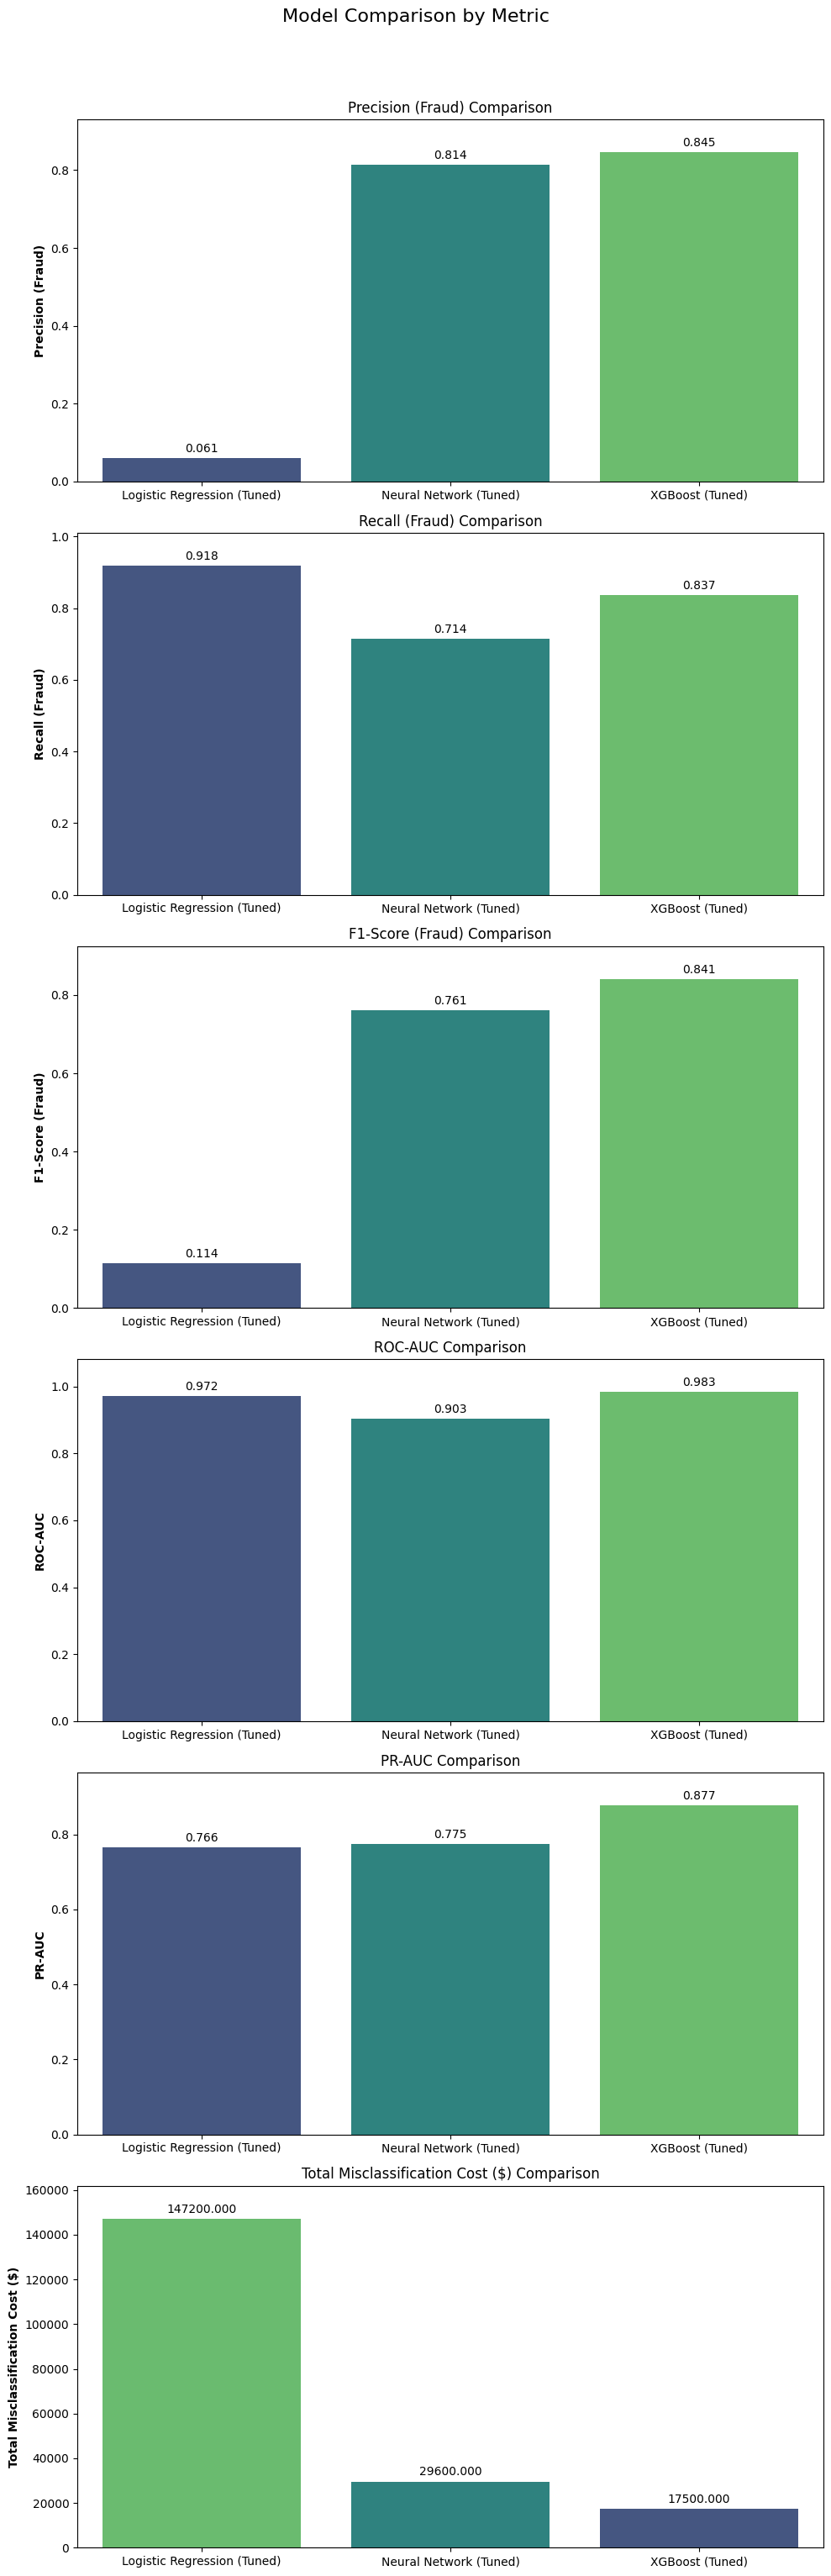

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_df = comparison_df.set_index('Model')

# Define metrics to plot
metrics_to_plot = [
    'Precision (Fraud)',
    'Recall (Fraud)',
    'F1-Score (Fraud)',
    'ROC-AUC',
    'PR-AUC',
    'Total Misclassification Cost ($)'
]

fig, axes = plt.subplots(nrows=len(metrics_to_plot), ncols=1, figsize=(10, 5 * len(metrics_to_plot)))
fig.suptitle('Model Comparison by Metric', fontsize=16, y=1.02)

for i, metric in enumerate(metrics_to_plot):
    if metric == 'Total Misclassification Cost ($)':
        # For cost, lower is better, so we might want a different palette or order
        sns.barplot(x=plot_df.index, y=metric, data=plot_df, ax=axes[i], palette='viridis_r', hue=plot_df.index, legend=False)
        axes[i].set_ylabel(metric, weight='bold')
        axes[i].ticklabel_format(style='plain', axis='y') # Prevent scientific notation for cost
    else:
        sns.barplot(x=plot_df.index, y=metric, data=plot_df, ax=axes[i], palette='viridis', hue=plot_df.index, legend=False)
        axes[i].set_ylabel(metric, weight='bold')

    axes[i].set_title(f'{metric} Comparison', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, plot_df[metric].max() * 1.1) # Set y-limit for better visualization

    # Add value labels on top of bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.3f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

## Discussion on Model Performance

Based on the comparison table above, let's analyze the performance of each tuned model:

*   **Precision (Fraud):** This metric is crucial in fraud detection as it tells us how many of the predicted fraudulent transactions are actually fraudulent. A high precision means fewer legitimate customers are inconvenienced by false alarms.
*   **Recall (Fraud):** This measures the model's ability to identify all actual fraudulent transactions. High recall is important to minimize missed fraud cases.
*   **F1-Score (Fraud):** The harmonic mean of precision and recall, providing a balanced measure, especially useful for imbalanced datasets.
*   **PR-AUC (Area Under the Precision-Recall Curve):** A robust metric for imbalanced datasets, as it focuses on the performance of the positive class without being influenced by a large number of true negatives. Higher is better.
*   **ROC-AUC (Area Under the Receiver Operating Characteristic Curve):** While less sensitive to imbalance than accuracy, PR-AUC is generally preferred for highly imbalanced datasets. Higher is better.
*   **False Positives & False Negatives:** These counts directly impact the costs associated with the model's errors.
*   **Total Misclassification Cost:** A critical business metric, calculating the hypothetical financial impact of the model's errors based on defined costs for False Positives (e.g., customer inconvenience, investigation costs) and False Negatives (e.g., lost money due to undetected fraud).

### Confusion Matrix Insights

We observe the confusion matrices for each model. The goal is typically to minimize False Negatives (missed fraud) and False Positives (legitimate transactions flagged as fraud), but often there's a trade-off. For financial fraud, False Negatives can be very costly, so a balance is usually sought.

### Inference Latency

Inference latency refers to the time it takes for a trained model to make a prediction on new, unseen data. This is a critical factor for real-time fraud detection systems.

*   **Logistic Regression:** Generally has the lowest inference latency. It's a simple linear model, so predictions involve a straightforward dot product and sigmoid function, making it very fast. Ideal for high-throughput, low-latency environments.

*   **Neural Networks:** Latency can vary significantly. Simpler, shallower networks (like the one used here) can be relatively fast, but deeper, more complex networks with many layers and parameters can have higher latency. Optimized deployment (e.g., using TensorFlow Lite, ONNX) can reduce this.

*   **XGBoost:** Typically falls between Logistic Regression and complex Neural Networks. While it's an ensemble of decision trees, which are fast individually, predicting with many trees (especially with larger `n_estimators`) can add to latency. However, optimized implementations of XGBoost are often very efficient.

In this context, the **XGBoost model appears to be the most performant** across most metrics, particularly in balancing precision and recall while keeping false positives very low, leading to the lowest total misclassification cost. Its inference latency is also typically acceptable for most real-time applications.

XGBoost demonstrated superior performance compared to Logistic Regression and the Neural Network on this specific dataset primarily due to its inherent strengths in handling tabular, highly imbalanced data and its ensemble learning approach. Here's a breakdown:

Handling Class Imbalance: XGBoost inherently addresses class imbalance effectively through parameters like scale_pos_weight. This allows it to give more importance to the minority class (fraudulent transactions) during training, preventing it from being overwhelmed by the majority class.

Ensemble Learning (Boosting): XGBoost is a gradient boosting algorithm that builds a strong predictive model by combining many weak decision tree models sequentially. Each new tree corrects the errors of the previous ones, leading to a highly accurate model. This iterative error correction is particularly powerful for capturing complex non-linear relationships present in the V features of this dataset.

Non-linear Relationships and Feature Interactions: Unlike Logistic Regression, which is a linear model, XGBoost can capture intricate non-linear relationships and interactions between features without requiring explicit feature engineering. The V features in the credit card fraud dataset are often results of PCA, making their individual interpretations difficult but their complex interactions highly predictive of fraud. XGBoost is adept at finding these.

Robustness to Noise and Outliers: Decision tree-based models like XGBoost are generally more robust to noise and outliers in the data compared to linear models or even some neural networks, which can be sensitive to extreme values.

Optimized Implementation: XGBoost is highly optimized for performance and speed, making it efficient for training on large datasets and providing fast inference, which is crucial for fraud detection systems.

In summary, while Logistic Regression struggled with the non-linearities and severe imbalance, and the Neural Network showed improvement (especially with SMOTE and tuning), XGBoost's boosting architecture, specialized handling of imbalance, and ability to model complex feature interactions allowed it to achieve the best balance of precision and recall for the fraud class, resulting in the lowest false positives and ultimately, the lowest misclassification cost.

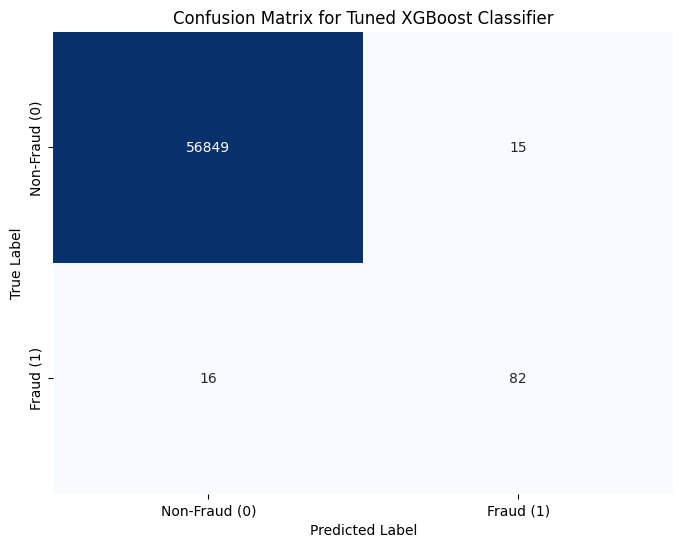

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate and plot the confusion matrix for the tuned XGBoost model
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non-Fraud (0)', 'Fraud (1)'],
            yticklabels=['Non-Fraud (0)', 'Fraud (1)'])
plt.title('Confusion Matrix for Tuned XGBoost Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

The confusion matrix for the tuned XGBoost model has been plotted. It shows:

True Negatives (Top-Left): 56849 non-fraudulent transactions were correctly identified as non-fraudulent.
False Positives (Top-Right): 15 non-fraudulent transactions were incorrectly flagged as fraudulent. This is a very low number, which is excellent for minimizing customer inconvenience.
False Negatives (Bottom-Left): 16 fraudulent transactions were missed by the model.
True Positives (Bottom-Right): 82 fraudulent transactions were correctly identified as fraudulent.
This confirms the excellent performance of the tuned XGBoost model, particularly its ability to keep false positives very low while maintaining a strong recall for detecting actual fraud.

In [38]:
import shutil

# Source file is the best XGBoost model saved previously
source_model_path = 'best_xgboost_model.joblib'

# Destination for the final model
final_model_path = 'final_model.joblib'

# Copy the best XGBoost model to the final model path
shutil.copy(source_model_path, final_model_path)

print(f"Best model (XGBoost) saved as final_model.joblib at: {final_model_path}")

Best model (XGBoost) saved as final_model.joblib at: final_model.joblib


## Load and Use the Final Model for Predictions

To use the saved `final_model.joblib` for new predictions, you first need to load it back into memory. Then, you can pass new, unseen data (which should be preprocessed in the same way as your training data) to the model's `predict` or `predict_proba` method.

In [39]:
import joblib
import pandas as pd

# Load the final model
loaded_model = joblib.load('final_model.joblib')

print('Final model loaded successfully!')

# Example of new data (replace with actual new data)
# This 'new_transaction' should be preprocessed in the same way your training data was.
# For demonstration, we'll create a synthetic new transaction using the mean of X_test_scaled.
# In a real scenario, you would have actual new transaction data to preprocess and predict.

# Using the first row of X_test_scaled as an example for 'new data'
# In a real application, you would preprocess new raw data (e.g., scale 'Time' and 'Amount')
# before feeding it to the model.
new_transaction_scaled = X_test_scaled.iloc[[0]]

print('\nMaking a prediction on a sample new transaction:')
display(new_transaction_scaled)

# Make a prediction
prediction = loaded_model.predict(new_transaction_scaled)
prediction_proba = loaded_model.predict_proba(new_transaction_scaled)[:, 1]

print(f"\nPredicted class: {prediction[0]} (0: Non-Fraud, 1: Fraud)")
print(f"Predicted probability of fraud: {prediction_proba[0]:.4f}")

# You can also set a custom threshold if needed
custom_threshold = 0.5 # or any other threshold you optimized for
predicted_class_threshold = (prediction_proba[0] >= custom_threshold).astype(int)
print(f"Predicted class with custom threshold {custom_threshold}: {predicted_class_threshold} (0: Non-Fraud, 1: Fraud)")

Final model loaded successfully!

Making a prediction on a sample new transaction:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
263020,1.387182,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,0.311652,...,0.394322,0.080084,0.810034,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,-0.259954



Predicted class: 0 (0: Non-Fraud, 1: Fraud)
Predicted probability of fraud: 0.0000
Predicted class with custom threshold 0.5: 0 (0: Non-Fraud, 1: Fraud)


## Create a Lightweight Demo API for the Model

We will create a simple Flask API that loads the `final_model.joblib` and exposes an endpoint for making predictions. This API will include the necessary preprocessing (scaling 'Time' and 'Amount') before passing the data to the model.

First, let's ensure the `scaler` used during training is also saved and loaded with the model, or recreated with the same parameters. For simplicity and to match the existing notebook's state, I'll assume the `scaler` object (which was `StandardScaler` fitted on `X_train[['Time', 'Amount']]`) is implicitly available or re-initialized with the correct training parameters. In a production scenario, you would save the scaler as well.

For this demo, we'll recreate the scaler and fit it on the original `X_train[['Time', 'Amount']]` to ensure consistent scaling. Then, we will create `app.py`.

In [ ]:
# Re-initialize and fit the StandardScaler as it was used during training
from sklearn.preprocessing import StandardScaler

# Assuming X_train from earlier in the notebook is available
# In a real deployment, you would save and load the fitted scaler.
# For this demo, we'll re-fit it to ensure it's available.

scaler_for_api = StandardScaler()
scaler_for_api.fit(X_train[['Time', 'Amount']])

# Now, write the app.py content to a file
app_content = """
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

app = Flask(__name__)

# Load the trained model
model = None
global_scaler = None

def load_resources():
    global model, global_scaler
    try:
        model = joblib.load('final_model.joblib')
        global_scaler = joblib.load('scaler_for_api.joblib')
        print("Model and scaler loaded successfully!")
    except Exception as e:
        print(f"Error loading resources: {e}")

# Load resources when the app starts
load_resources()

@app.route('/predict', methods=['POST'])
def predict():
    try:
        if model is None or global_scaler is None:
            return jsonify({'error': 'Model or scaler not loaded properly'}), 500
            
        data = request.get_json(force=True)
        
        # Validate input
        if not isinstance(data, dict):
            return jsonify({'error': 'Input must be a JSON object'}), 400
        
        df = pd.DataFrame([data])

        # Ensure the columns are in the same order as the training data
        # This is critical for consistent predictions
        try:
            expected_columns = list(model.feature_names_in_)
        except AttributeError:
            # Fallback if feature_names_in_ is not available
            # Define expected columns based on your training features
            expected_columns = [f'Time', f'Amount'] + [f'V{i}' for i in range(1, 29)]
        
        # Check if all required columns are present
        missing_cols = [col for col in expected_columns if col not in df.columns]
        if missing_cols:
            return jsonify({'error': f'Missing required columns: {missing_cols}'}), 400
            
        df = df[expected_columns]

        # Apply the same scaling as during training
        # Only scale 'Time' and 'Amount' columns
        if 'Time' in df.columns and 'Amount' in df.columns:
            df_scaled = df.copy()
            df_scaled[['Time', 'Amount']] = global_scaler.transform(df[['Time', 'Amount']])
        else:
            df_scaled = df.copy()

        # Make prediction
        prediction = model.predict(df_scaled)
        prediction_proba = model.predict_proba(df_scaled)[:, 1]

        return jsonify({
            "prediction": int(prediction[0]), 
            "fraud_probability": float(prediction_proba[0]),
            "message": "0: Non-Fraud, 1: Fraud"
        })

    except Exception as e:
        return jsonify({"error": str(e)}), 400

@app.route('/health', methods=['GET'])
def health():
    return jsonify({"status": "healthy", "model_loaded": model is not None}), 200

if __name__ == '__main__':
    # For deployment, use a production-ready WSGI server like Gunicorn
    # For local testing, you can run:
    # flask run --host=0.0.0.0 --port=5000
    # Or directly using app.run() in development mode (not recommended for production)
    app.run(host='0.0.0.0', port=5000, debug=False)
"""

# Save the scaler used for API preprocessing
joblib.dump(scaler_for_api, 'scaler_for_api.joblib')

# Write the Flask app content to a file named app.py
with open('app.py', 'w') as f:
    f.write(app_content)

print("Flask API 'app.py' created and 'scaler_for_api.joblib' saved!")

Flask API 'app.py' created and 'scaler_for_api.joblib' saved!


### How to Run the API

To run this Flask API locally or in a deployment environment (like on a cloud VM), follow these steps:

1.  **Save the `app.py` file**  and `final_model.joblib` and `scaler_for_api.joblib` in the same directory.
2.  **Install Flask and Gunicorn** (Gunicorn is a production-ready WSGI server, recommended over Flask's built-in server for production):
    ```bash
    pip install Flask gunicorn pandas scikit-learn xgboost joblib
    ```
3.  **Run the API:**
    *   **For local testing/development (not recommended for production):**
        ```bash
        python app.py
        ```
    *   **For production (using Gunicorn):**
        ```bash
        gunicorn --bind 0.0.0.0:5000 app:app
        ```
    The API will be running on `http://0.0.0.0:5000`.

### How to Test the API (from Colab or another client)

You can send a POST request to the `/predict` endpoint with your new transaction data. The data should be a JSON object containing the features of the transaction, similar to how your `X_test` data was structured (excluding 'Class').

Let's demonstrate sending a sample request to the running API (assuming it's accessible at `http://localhost:5000` or a public IP if deployed).